**AI-Based Cyclone Path and Intensity Forecasting**

This project aims to develop an AI/ML model that can predict the path (latitude and longitude) and intensity (maximum wind speed and minimum central pressure) of tropical cyclones. By leveraging historical cyclone data from the CMA Best Track dataset, the model provides accurate forecasts that can help in early warning systems and disaster preparedness.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

**LOADING THE DATASET**

In [2]:
data = pd.read_csv("CMA_Best_Track_Data.csv", low_memory=False)


**DATA PREPROCESSING**

In [3]:
data.head()

,International Number ID,Tropical Cyclone Number,Chinese Tropical Cyclone Data,Tropical Cyclone End Record,Number of Hours between Paths per Line,Name,Time,Grade,Latitude,Longitude,Minimum Central Pressure,Maximum Wind Speed,Average Wind Speed
0,0,1,0000,0,6,Carmen,1949-01-13 00:00:00,0,5.7,139.9,1006,0,NaN
1,0,1,0000,0,6,Carmen,1949-01-13 06:00:00,0,5.9,139.3,1006,0,NaN
2,0,1,0000,0,6,Carmen,1949-01-13 12:00:00,0,6.3,138.7,1006,0,NaN
3,0,1,0000,0,6,Carmen,1949-01-13 18:00:00,0,6.7,138.0,1006,0,NaN
4,0,1,0000,0,6,Carmen,1949-01-14 00:00:00,0,7.2,137.3,1005,0,NaN


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71705 entries, 0 to 71704
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   International Number ID                 71705 non-null  int64  
 1   Tropical Cyclone Number                 71705 non-null  int64  
 2   Chinese Tropical Cyclone Data           71705 non-null  object 
 3   Tropical Cyclone End Record             71705 non-null  int64  
 4   Number of Hours between Paths per Line  71705 non-null  int64  
 5   Name                                    71705 non-null  object 
 6   Time                                    71705 non-null  object 
 7   Grade                                   71705 non-null  int64  
 8   Latitude                                71705 non-null  float64
 9   Longitude                               71705 non-null  float64
 10  Minimum Central Pressure                71705 non-null  in

In [5]:
data.describe

<bound method NDFrame.describe of        International Number ID  Tropical Cyclone Number  \
0                            0                        1   
1                            0                        1   
2                            0                        1   
3                            0                        1   
4                            0                        1   
...                        ...                      ...   
71700                     2225                       29   
71701                     2225                       29   
71702                     2225                       29   
71703                     2225                       29   
71704                     2225                       29   

      Chinese Tropical Cyclone Data  Tropical Cyclone End Record  \
0                              0000                            0   
1                              0000                            0   
2                              0000                  

In [6]:
data.isnull().sum()

International Number ID                       0
Tropical Cyclone Number                       0
Chinese Tropical Cyclone Data                 0
Tropical Cyclone End Record                   0
Number of Hours between Paths per Line        0
Name                                          0
Time                                          0
Grade                                         0
Latitude                                      0
Longitude                                     0
Minimum Central Pressure                      0
Maximum Wind Speed                            0
Average Wind Speed                        70971
dtype: int64

In [7]:
data = data.drop(columns=["Chinese Tropical Cyclone Data", "Average Wind Speed", "Name"])


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71705 entries, 0 to 71704
Data columns (total 10 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   International Number ID                 71705 non-null  int64  
 1   Tropical Cyclone Number                 71705 non-null  int64  
 2   Tropical Cyclone End Record             71705 non-null  int64  
 3   Number of Hours between Paths per Line  71705 non-null  int64  
 4   Time                                    71705 non-null  object 
 5   Grade                                   71705 non-null  int64  
 6   Latitude                                71705 non-null  float64
 7   Longitude                               71705 non-null  float64
 8   Minimum Central Pressure                71705 non-null  int64  
 9   Maximum Wind Speed                      71705 non-null  int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 5.5+ MB


**EXTRACT TEMPORAL FEATURES**

In [9]:
data['Time'] = pd.to_datetime(data['Time'], errors='coerce')

In [10]:
print(data['Time'].isna().sum())

0


In [11]:
data = data.dropna(subset=['Time']).reset_index(drop=True)

In [12]:
data['Year'] = data['Time'].dt.year
data['Month'] = data['Time'].dt.month
data['Day'] = data['Time'].dt.day
data['Hour'] = data['Time'].dt.hour

In [13]:
data = data.sort_values(by=['International Number ID', 'Time']).reset_index(drop=True)

**FEATURE ENGINEERING**

In [16]:
data['Prev_Lat'] = data.groupby('International Number ID')['Latitude'].shift(1)
data['Prev_Lon'] = data.groupby('International Number ID')['Longitude'].shift(1)
data['Prev_MaxWind'] = data.groupby('International Number ID')['Maximum Wind Speed'].shift(1)


data = data.dropna().reset_index(drop=True)


**FEATURES AND TARGET**

In [20]:
#Features
X = data[['Year', 'Month', 'Day', 'Hour',
          'Prev_Lat', 'Prev_Lon', 'Prev_MaxWind',
          'Minimum Central Pressure']]

# Targets
y_path = data[['Latitude', 'Longitude']]            
y_intensity = data['Maximum Wind Speed']            

**TRAIN TEST SPLITING**

In [21]:
cyclone_ids = data['International Number ID'].unique()
train_ids, test_ids = train_test_split(cyclone_ids, test_size=0.2, random_state=42)

X_train = data[data['International Number ID'].isin(train_ids)][X.columns]
y_path_train = data[data['International Number ID'].isin(train_ids)][['Latitude', 'Longitude']]
y_intensity_train = data[data['International Number ID'].isin(train_ids)]['Maximum Wind Speed']

X_test = data[data['International Number ID'].isin(test_ids)][X.columns]
y_path_test = data[data['International Number ID'].isin(test_ids)][['Latitude', 'Longitude']]
y_intensity_test = data[data['International Number ID'].isin(test_ids)]['Maximum Wind Speed']

**SCALING FEATURES**

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, y_path_train.shape, y_intensity_train.shape)
print("Test shape:", X_test_scaled.shape, y_path_test.shape, y_intensity_test.shape)

Train shape: (70392, 8) (70392, 2) (70392,)
Test shape: (1001, 8) (1001, 2) (1001,)


**CYCLONE PATTERN VISUALIZATION**

In [23]:
#Cyclone track

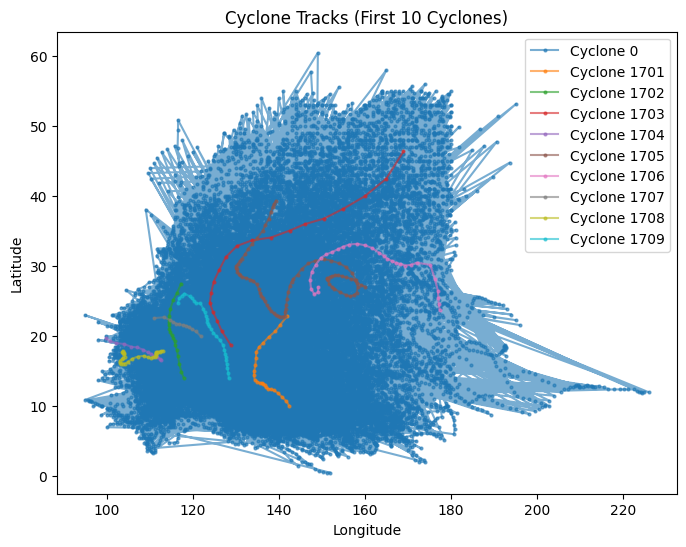

In [25]:
plt.figure(figsize=(8,6))
for cid in data['International Number ID'].unique()[:10]:  
    subset = data[data['International Number ID'] == cid]
    plt.plot(subset['Longitude'], subset['Latitude'], marker='o', markersize=2, alpha=0.6, label=f"Cyclone {cid}")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Cyclone Tracks (First 10 Cyclones)")
plt.legend()
plt.show()

In [26]:
# Intensity distribution 

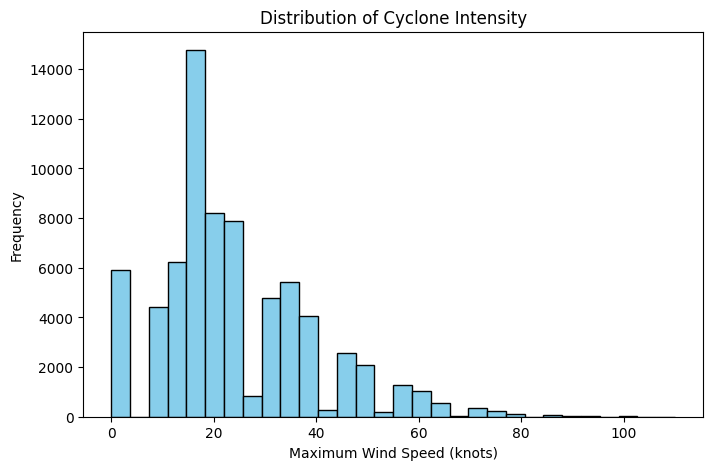

In [27]:
plt.figure(figsize=(8,5))
plt.hist(data['Maximum Wind Speed'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Maximum Wind Speed (knots)")
plt.ylabel("Frequency")
plt.title("Distribution of Cyclone Intensity")
plt.show()


In [28]:
# Pressure Vs Wind speed

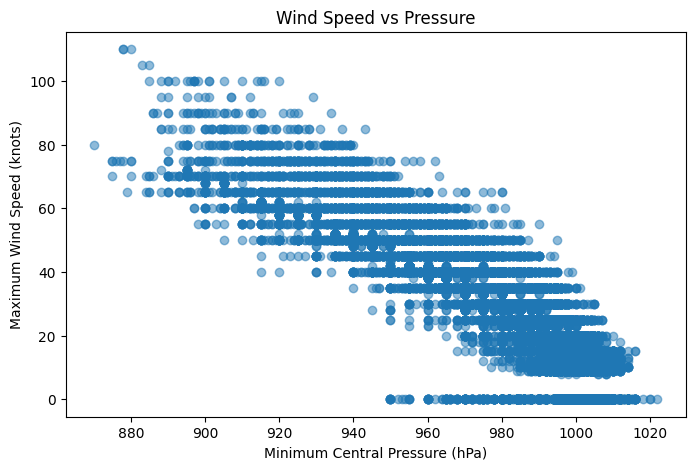

In [29]:
plt.figure(figsize=(8,5))
plt.scatter(data['Minimum Central Pressure'], data['Maximum Wind Speed'], alpha=0.5)
plt.xlabel("Minimum Central Pressure (hPa)")
plt.ylabel("Maximum Wind Speed (knots)")
plt.title("Wind Speed vs Pressure")
plt.show()


In [34]:
corr = data['Maximum Wind Speed'].corr(data['Minimum Central Pressure'])
print("Correlation between Wind Speed and Pressure:", corr)

Correlation between Wind Speed and Pressure: -0.9083957120056205


In [31]:
# Seasonal cyclone frequency

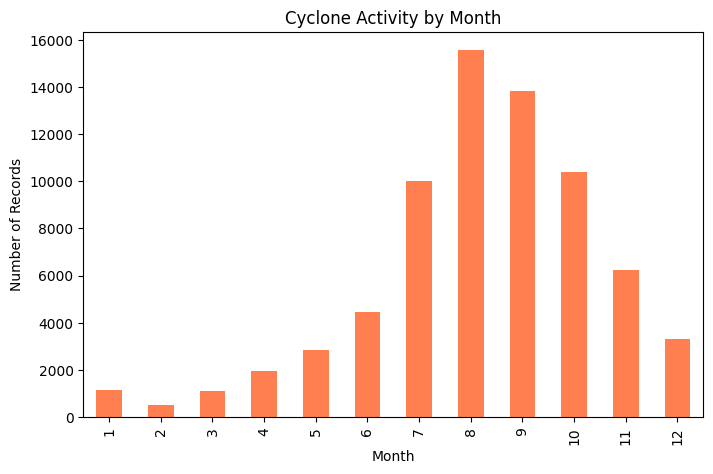

In [32]:
plt.figure(figsize=(8,5))
data['Month'].value_counts().sort_index().plot(kind='bar', color='coral')
plt.xlabel("Month")
plt.ylabel("Number of Records")
plt.title("Cyclone Activity by Month")
plt.show()
